# Set Up

This notebook follows the lecture flow (SSL -> the two-stage Speech SSL framework -> wav2vec 2.0 -> HuBERT) and lets us touch each idea with real pretrained models. We first install the libraries we need. The `transformers` library provides the pretrained SSL models, `torchaudio` and `librosa` handle audio I/O and visualization, and `scikit-learn` is used later for the K-means quantizer and the linear probe. We then fix a single global sample rate of 16 kHz, because both wav2vec 2.0 and HuBERT were pretrained on 16 kHz speech and expect the same rate at inference time.

Before running, set the runtime to GPU: `Runtime > Change runtime type > Hardware accelerator > GPU (T4)`.

In [ ]:
%%capture

# Install the core packages (transformers for pretrained SSL models, audio + ML utils)
!pip install -U "transformers>=4.40" torchaudio librosa scikit-learn matplotlib soundfile datasets

Import the libraries used throughout the notebook.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd

Select the compute device and fix the sample rate. Every audio in this notebook is 16 kHz.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLERATE = 16000

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if device == "cpu":
    print("Warning: running on CPU. Switch to a GPU runtime for a much faster session.")

# Speech Data

## Load a Sample Utterance

The input to a speech SSL model is the raw waveform. The Feature Encoder shown in the slides consumes this waveform directly, so there is no hand-crafted feature step on our side. Two conditions matter for the input: the sample rate must be 16 kHz, and the signal must be a 1-D float array. We load one short example utterance from a tiny LibriSpeech subset (already 16 kHz) and resample defensively in case the source rate ever differs.

In [ ]:
from datasets import load_dataset

# A very small LibriSpeech subset used widely in HuggingFace examples
ds = load_dataset("hf-internal-testing/librispeech_asr_dummy", split="validation")

In [ ]:
sample = ds[0]
wav = np.asarray(sample["audio"]["array"], dtype=np.float32)
sr_in = sample["audio"]["sampling_rate"]

print(f"source sample rate : {sr_in}")
print(f"duration (s)       : {len(wav) / sr_in:.2f}")
print(f"reference text     : {sample['text'][:]} ...")

Resample to 16 kHz if needed, then listen to the clip.

In [ ]:
if sr_in != SAMPLERATE:
    wav = librosa.resample(wav, orig_sr=sr_in, target_sr=SAMPLERATE)

print(f"waveform shape : {wav.shape} | dtype : {wav.dtype}")
ipd.display(ipd.Audio(wav, rate=SAMPLERATE))

We plot the waveform next to its mel-spectrogram. The waveform is the actual model input; the mel-spectrogram is only a visualization to help us read the signal.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))

# Left: raw waveform (the model input)
ax[0].plot(np.arange(len(wav)) / SAMPLERATE, wav, lw=0.5)
ax[0].set(title="Waveform (raw input)", xlabel="time (s)", ylabel="amplitude")

# Right: mel-spectrogram (visualization only)
mel = librosa.feature.melspectrogram(y=wav, sr=SAMPLERATE, n_mels=80)
mel_db = librosa.power_to_db(mel, ref=np.max)
img = librosa.display.specshow(mel_db, sr=SAMPLERATE, x_axis="time", y_axis="mel", ax=ax[1])
ax[1].set(title="Mel-spectrogram (for reference)")
fig.colorbar(img, ax=ax[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

# The Speech SSL Framework

## Load a Pretrained Upstream Model

Recall the two-stage framework from the slides. In Stage 1 the upstream model is pretrained on large amounts of unlabeled speech. In Stage 2 we either keep it frozen and use its representations, or fine-tune it with labeled data. We do not train Stage 1 ourselves. Instead we download `facebook/wav2vec2-base`, which is the pretrained-only model (not fine-tuned for ASR), freeze it, and read out its representations.

One naming caution. In HuggingFace the input pre-processor is called a `FeatureExtractor`, and the model's internal CNN is also named `.feature_extractor`. They are different objects. We separate them explicitly in the next section.

In [ ]:
from transformers import AutoFeatureExtractor, Wav2Vec2Model

W2V_NAME = "facebook/wav2vec2-base"

# processor: normalizes the waveform and turns it into a batched tensor
processor = AutoFeatureExtractor.from_pretrained(W2V_NAME)

# model: the pretrained upstream network
w2v = Wav2Vec2Model.from_pretrained(W2V_NAME).to(device).eval()

Freeze the model. In Stage 2 with a frozen upstream, no gradients flow into these parameters.

In [ ]:
for p in w2v.parameters():
    p.requires_grad_(False)

n_params = sum(p.numel() for p in w2v.parameters())
print(f"model parameters : {n_params / 1e6:.1f} M (all frozen)")

## Extract Representations

We now pass the waveform through the frozen model and read the representation. The processor prepares the input, and `output_hidden_states=True` gives us every layer's output in addition to the final one. The final representation is what downstream tasks (ASR, speaker, emotion, and so on) are built on.

In [ ]:
# waveform -> processor -> model
inputs = processor(wav, sampling_rate=SAMPLERATE, return_tensors="pt").input_values.to(device)

with torch.no_grad():
    out = w2v(inputs, output_hidden_states=True)

rep = out.last_hidden_state  # [1, T, 768] : contextual representation from the final layer

Check the shapes and the downsampling introduced by the Feature Encoder.

In [ ]:
print(f"input samples    : {inputs.shape[-1]}")
print(f"representation   : {tuple(rep.shape)}  -> (batch, frames T, dim 768)")

# The convolutional Feature Encoder has stride product 320, so 16 kHz -> 50 frames/s
ds_factor = inputs.shape[-1] / rep.shape[1]
print(f"downsampling     : ~{ds_factor:.0f}x  ->  {ds_factor / SAMPLERATE * 1000:.0f} ms per frame, "
      f"{SAMPLERATE / ds_factor:.0f} frames/s")

The 16,000 samples per second of waveform have become a sequence of 768-dimensional vectors at 50 frames per second. This vector sequence is the representation. The key point is that we obtained it without training Stage 1 ourselves, which is exactly what makes self-supervised pretraining useful.

# wav2vec 2.0 Internals

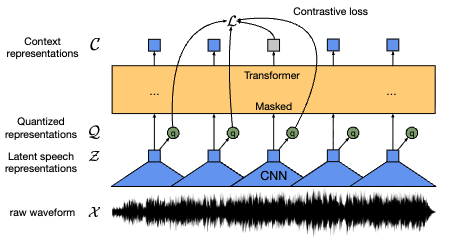

## Feature Encoder vs Transformer

The slides split wav2vec 2.0 into a convolutional Feature Encoder that produces local features `z`, and a Transformer that contextualizes them into `c`. We extract both from the same utterance and compare their shapes. The CNN output is 512-dimensional and the Transformer output is 768-dimensional, but they share the same number of frames.

In [ ]:
with torch.no_grad():
    # (a) Feature Encoder (CNN) only: call the model's internal .feature_extractor
    z = w2v.feature_extractor(inputs)   # [1, 512, T]
    z = z.transpose(1, 2)               # [1, T, 512]

    # (b) full network output (reuse rep from the previous section)
    c = rep                             # [1, T, 768]

print(f"CNN features z         : {tuple(z.shape)}  -> local, 512-d")
print(f"Transformer features c : {tuple(c.shape)}  -> contextual, 768-d")
print(f"same number of frames  : {z.shape[1] == c.shape[1]}")

## Layer-wise Representations

wav2vec 2.0 has 12 Transformer layers, and the representation changes character from layer to layer. To build intuition we compute, within one layer, the cosine self-similarity between all pairs of frames. A bright block near the diagonal means nearby frames are similar. Comparing a shallow, a middle, and a deep layer shows how this structure evolves with depth.

This matters in practice. When we later feed a frozen representation to a downstream task, the choice of layer affects accuracy, and wav2vec 2.0 models tend to carry the most phonetic information in their middle layers.

In [ ]:
def self_similarity(h):
    # h : [T, D] -> [T, T] cosine similarity matrix
    h = torch.nn.functional.normalize(h, dim=-1)
    return (h @ h.T).cpu().numpy()

hidden = out.hidden_states       # tuple of length 13 : (embeddings, layer 1, ..., layer 12)
layers_to_show = [1, 6, 11]      # shallow / middle / deep

In [ ]:
fig, axes = plt.subplots(1, len(layers_to_show), figsize=(13, 4))

for ax, L in zip(axes, layers_to_show):
    S = self_similarity(hidden[L][0])
    im = ax.imshow(S, origin="lower", aspect="auto", cmap="magma")
    ax.set(title=f"Layer {L}", xlabel="frame", ylabel="frame")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Frame self-similarity per layer (brighter = more similar)", y=1.02)
plt.tight_layout()
plt.show()

## Masking and Contrastive Learning

During pretraining, wav2vec 2.0 masks a subset of time steps in the CNN output `z` and learns representations at the masked positions that are close to the correct quantized targets, chosen against distractors. This is a contrastive objective, and it is close in spirit to predicting a hidden sound from its surrounding context.

We are not training here. The cell below only visualizes what masking looks like, by marking the masked time spans on the mel-spectrogram, so the objective in the slides has a concrete picture.

In [ ]:
mel_db2 = librosa.power_to_db(
    librosa.feature.melspectrogram(y=wav, sr=SAMPLERATE, n_mels=80), ref=np.max
)
n_frames = mel_db2.shape[1]

# Sample masked spans (wav2vec 2.0 uses a default span length of 10 frames)
rng = np.random.default_rng(0)
mask = np.zeros(n_frames, dtype=bool)
for s in rng.choice(n_frames, size=max(1, n_frames // 15), replace=False):
    mask[s:s + 10] = True

fig, ax = plt.subplots(figsize=(12, 3.2))
librosa.display.specshow(mel_db2, sr=SAMPLERATE, x_axis="frames", y_axis="mel", ax=ax)
for f in np.where(mask)[0]:
    ax.axvspan(f - 0.5, f + 0.5, color="cyan", alpha=0.35)
ax.set(title="Concept: masked spans (cyan) are predicted from context (contrastive pretraining)")
plt.tight_layout()
plt.show()

print(f"masked {mask.sum()} of {n_frames} frames ({mask.mean() * 100:.0f}%)")

# HuBERT and Discrete Units

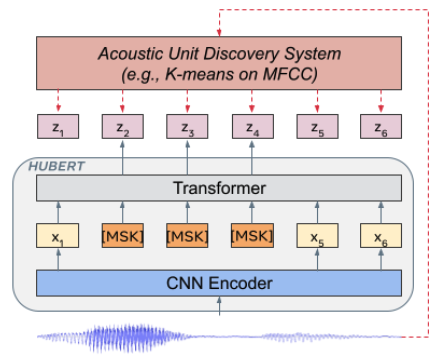

## Load HuBERT

The central piece of the HuBERT training figure in the slides is the K-means quantizer. HuBERT clusters continuous speech representations into discrete labels with K-means, and then learns to predict those labels in a BERT-style masked-prediction task. These discrete units are the starting point for textless NLP, because they let us treat sound like a sequence of tokens.

Here we reproduce that quantizer directly: we take representations from a pretrained HuBERT model and run K-means on them to obtain discrete units.

In [ ]:
from transformers import HubertModel

HUBERT_NAME = "facebook/hubert-base-ls960"
hb_proc = AutoFeatureExtractor.from_pretrained(HUBERT_NAME)
hubert = HubertModel.from_pretrained(HUBERT_NAME).to(device).eval()

for p in hubert.parameters():
    p.requires_grad_(False)

A small helper that returns per-frame features from a chosen HuBERT layer. Layer 6 is a common choice for unit extraction with HuBERT-base.

In [ ]:
UNIT_LAYER = 6

@torch.no_grad()
def hubert_frames(waveform, layer=UNIT_LAYER):
    x = hb_proc(waveform, sampling_rate=SAMPLERATE, return_tensors="pt").input_values.to(device)
    h = hubert(x, output_hidden_states=True).hidden_states[layer][0]  # [T, 768]
    return h.cpu().numpy()

## Cluster Frames into Discrete Units

We gather frame features from several utterances and fit K-means. Each cluster centroid becomes one discrete unit, and predicting the unit index for each frame turns a continuous representation into an integer sequence. We use 50 units here for a quick demo; real HuBERT typically uses 100 to 500.

In [ ]:
# Collect frames from a few utterances as K-means training data
some = [np.asarray(ds[i]["audio"]["array"], np.float32) for i in range(8)]
frames = [hubert_frames(w) for w in some]

X = np.concatenate(frames, axis=0)
print(f"frames for K-means : {X.shape}  -> (num frames, 768)")

In [ ]:
from sklearn.cluster import KMeans

N_UNITS = 50
km = KMeans(n_clusters=N_UNITS, n_init=4, random_state=0).fit(X)

# Convert the first utterance into a sequence of discrete units
units = km.predict(frames[0])
print("discrete units of the first utterance (first 40 frames):")
print(units[:40])
print(f"\n{len(units)} frames -> {len(np.unique(units))} distinct units used (out of {N_UNITS})")

Overlay the units on the mel-spectrogram of the same utterance. As the sound changes, the unit index tends to change with it.

In [ ]:
w0 = some[0]
mel0 = librosa.power_to_db(
    librosa.feature.melspectrogram(y=w0, sr=SAMPLERATE, n_mels=80), ref=np.max
)

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})

librosa.display.specshow(mel0, sr=SAMPLERATE, x_axis="frames", y_axis="mel", ax=ax[0])
ax[0].set(title="Mel-spectrogram")

t = np.arange(len(units))
ax[1].scatter(t, np.zeros_like(t), c=units, cmap="tab20", marker="|", s=400)
ax[1].set(yticks=[], xlabel="frame",
          title=f"HuBERT discrete units (layer {UNIT_LAYER}, K={N_UNITS})")

plt.tight_layout()
plt.show()

Repeated occurrences of the same sound tend to receive the same unit index. Once speech is written as a sequence of integers like this, a language model can be attached on top, which is the idea behind textless NLP. The quantizer plus masked prediction shown in the slides uses exactly these units as targets.

# Downstream Task: Spoken Digit Classification

## Prepare the Dataset

This is Stage 2 of the framework, done end to end. We put a lightweight linear classifier on top of the frozen SSL representation, solve a small downstream task, and compare against a classical feature (MFCC). The comparison answers the practical question: are the self-supervised representations actually better?

The task is spoken-digit classification (0 to 9) on the Free Spoken Digit Dataset, which is tiny. The method is: one utterance -> frame representations -> mean-pool over time -> one utterance vector -> logistic regression.

In [ ]:
# Download FSDD (about 10 MB, 3000 short clips: 6 speakers x 10 digits x 50)
!git clone -q https://github.com/Jakobovski/free-spoken-digit-dataset.git

In [ ]:
import glob
import os

files = sorted(glob.glob("free-spoken-digit-dataset/recordings/*.wav"))
labels = [int(os.path.basename(f).split("_")[0]) for f in files]  # filename: {digit}_{speaker}_{idx}.wav

print(f"total files : {len(files)}")
print(f"example     : {os.path.basename(files[0])} -> label {labels[0]}")

## Feature Extractors

We define three ways to turn one utterance into a fixed-length vector: an MFCC baseline, a wav2vec 2.0 representation, and a HuBERT representation. The two SSL extractors mean-pool the final hidden state over time. Keeping the pooling and the classifier identical isolates the effect of the input representation.

In [ ]:
def load_wav(path):
    y, _ = librosa.load(path, sr=SAMPLERATE)  # FSDD is 8 kHz, resampled to 16 kHz here
    return y.astype(np.float32)

def feat_mfcc(y):
    m = librosa.feature.mfcc(y=y, sr=SAMPLERATE, n_mfcc=40)
    return m.mean(axis=1)  # mean over time -> 40-d

@torch.no_grad()
def feat_ssl(y, model, proc):
    x = proc(y, sampling_rate=SAMPLERATE, return_tensors="pt").input_values.to(device)
    h = model(x).last_hidden_state[0]  # [T, 768]
    return h.mean(0).cpu().numpy()     # mean-pool over time -> 768-d

## Extract Features

Run all three extractors over every clip. On a GPU this takes a few minutes. To shorten it, slice `files` and `labels` before this cell.

In [ ]:
from tqdm.auto import tqdm

F_mfcc, F_w2v, F_hub = [], [], []
for f in tqdm(files, desc="feature extraction"):
    y = load_wav(f)
    F_mfcc.append(feat_mfcc(y))
    F_w2v.append(feat_ssl(y, w2v, processor))
    F_hub.append(feat_ssl(y, hubert, hb_proc))

F_mfcc = np.stack(F_mfcc)
F_w2v = np.stack(F_w2v)
F_hub = np.stack(F_hub)
y_all = np.array(labels)

print("feature shapes :", F_mfcc.shape, F_w2v.shape, F_hub.shape)

## Train and Compare

For each feature set we train the same logistic-regression probe under the same split, and report test accuracy. Only the input representation differs across the three runs.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def evaluate(X, name):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y_all, test_size=0.25, stratify=y_all, random_state=0
    )
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    clf.fit(Xtr, ytr)
    acc = clf.score(Xte, yte)
    print(f"{name:>10s} : test accuracy = {acc * 100:5.1f}%")
    return acc

print("frozen representation + linear probe")
print("-" * 40)
results = {
    "MFCC": evaluate(F_mfcc, "MFCC"),
    "wav2vec2": evaluate(F_w2v, "wav2vec2"),
    "HuBERT": evaluate(F_hub, "HuBERT"),
}

Plot the comparison.

In [ ]:
plt.figure(figsize=(5.5, 3.6))
names = list(results.keys())
accs = [results[n] * 100 for n in names]

bars = plt.bar(names, accs, color=["#9aa0a6", "#4285F4", "#EA4335"])
for b, a in zip(bars, accs):
    plt.text(b.get_x() + b.get_width() / 2, a + 0.5, f"{a:.1f}%", ha="center", fontsize=11)

plt.ylabel("test accuracy (%)")
plt.ylim(0, 105)
plt.title("Linear probe on frozen representations")
plt.tight_layout()
plt.show()

The classifier and the data are held fixed, so the accuracy gap comes entirely from the input representation. The self-supervised features from wav2vec 2.0 and HuBERT were learned without labels, yet they give a much better probe than MFCC. This is the payoff of the Stage 1 -> Stage 2 framework.

# Exercises

Exercises:

1. Layer sweep. In the downstream section, replace `last_hidden_state` with `hidden_states[L]` and mean-pool that layer instead. Plot accuracy against layer index. Which layer is best?
2. Number of units. Set `N_UNITS` to 20, 50, and 100 and observe how finely the units segment the sound.
3. A different task.